## Bike Rental Demand Forecasting and Anomaly Detection Across Two Cities

Project Goal

1. Predict hourly bike rental demand.
2. Detect unusual demand spikes and drops.
3. Compare results across 2 independent datasets (Washington DC and Seoul).

Phase 1: Project Setup 

1. Define problem statement in 3-5 lines.
2. Download both datasets from UCI.
3. Create a short data dictionary for each dataset.
4. Confirm target variable:
5. DC dataset: cnt
6. Seoul dataset: Rented Bike Count

Phase 2: Data Cleaning and Standardization 
1. Load both datasets.
2. Parse date and hour fields.
3. Handle missing values (if any).
4. Standardize column names so both datasets share a common schema.
5. Keep core columns:
 datetime
 demand
 temperature
 humidity
 windspeed
 rainfall/snowfall
 holiday
 season

Phase 3: Exploratory Data Analysis

1. Plot demand over time.
2. Compare weekday vs weekend demand.
3. Compare seasonal demand.
4. Analyze weather effect on demand.
5. Write 5-7 key insights.

Phase 4: Feature Engineering

1. Create time features:
 hour
 day_of_week
 month
 is_weekend
2. Create lag features (for time dependency), like previous hour demand.
3. Create rolling mean features (for smoothing), for example 24-hour average.
4. Scale numeric features if model needs it.

 Phase 5: Forecasting Models

1. Build baseline model (Linear Regression or Random Forest Regressor).
2. Train and test on each dataset separately.
3. Evaluate with:
MAE
RMSE
4. Save prediction vs actual values.

Phase 6: Cross-Dataset Generalization 

1. Train on DC, test on Seoul.
2. Train on Seoul, test on DC.
3. Compare error increase/decrease.
4. Explain why transfer works or fails (climate, behavior, holidays, data differences).

Phase 7: Anomaly Detection Using Residuals 

1. Compute residual = actual - predicted.
2. Define anomaly rule:
abs(residual) > 2 or 3 standard deviations
Mark anomalies in timeline plots.
3. Categorize anomalies:
unexpected spike
unexpected drop
4. Discuss possible causes (weather extremes, holidays, events).

Phase 8: Final Report and Presentation 

1. Problem and motivation.
2. Dataset summary (prove 2 independent datasets used).
3. Methods used.
4. Main results and metric tables.
5. Anomaly examples with plots.
6. Limitations and future improvements.

In [50]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  


In [51]:
# Update these paths to where you saved files
dc_path = "data/hour.csv"              # UCI Bike Sharing (DC)
seoul_path = "data/SeoulBikeData.csv"  # UCI Seoul Bike

dc = pd.read_csv(dc_path)
seoul = pd.read_csv(seoul_path, encoding="latin1")

print("DC shape:", dc.shape)
print("Seoul shape:", seoul.shape)

print("\nDC columns:")
print(dc.columns.tolist())

print("\nSeoul columns:")
print(seoul.columns.tolist())

dc.head(), seoul.head()

DC shape: (17379, 17)
Seoul shape: (8760, 14)

DC columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Seoul columns:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


(   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
 0        1  2011-01-01       1   0     1   0        0        6           0   
 1        2  2011-01-01       1   0     1   1        0        6           0   
 2        3  2011-01-01       1   0     1   2        0        6           0   
 3        4  2011-01-01       1   0     1   3        0        6           0   
 4        5  2011-01-01       1   0     1   4        0        6           0   
 
    weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
 0           1  0.24  0.2879  0.81        0.0       3          13   16  
 1           1  0.22  0.2727  0.80        0.0       8          32   40  
 2           1  0.22  0.2727  0.80        0.0       5          27   32  
 3           1  0.24  0.2879  0.75        0.0       3          10   13  
 4           1  0.24  0.2879  0.75        0.0       0           1    1  ,
          Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
 0  01/12/20

In [52]:
seoul

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [53]:
dc

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [ ]:
# Step 2: Standardize both datasets to same schema

# --- DC dataset ---
dc_std = dc.copy()

# Build datetime from dteday + hr
dc_std["datetime"] = pd.to_datetime(dc_std["dteday"]) + pd.to_timedelta(dc_std["hr"], unit="h")

dc_std = dc_std.rename(columns={
    "cnt": "demand",
    "temp": "temperature",
    "hum": "humidity",
    "holiday": "holiday",
    "season": "season"
})

# Normalize categorical columns into a unified numeric format.
dc_std["holiday"] = pd.to_numeric(dc_std["holiday"], errors="coerce").astype(int)
dc_std["season"] = pd.to_numeric(dc_std["season"], errors="coerce").astype(int)

# DC weather fields are already normalized in the original dataset docs.
dc_std = dc_std[["datetime", "demand", "temperature", "humidity", "windspeed", "holiday", "season"]].copy()
dc_std["rainfall"] = 0.0  # not directly available in DC set; keep model-ready without NaNs
dc_std["city"] = "DC"
dc_std["is_operational"] = 1  # DC data has no shutdown flag in this file, so keep all rows

# --- Seoul dataset ---
seoul_std = seoul.copy()

# Parse datetime from Date + Hour
seoul_std["datetime"] = pd.to_datetime(seoul_std["Date"], dayfirst=True) + pd.to_timedelta(seoul_std["Hour"], unit="h")

# Handle possible column-name variants in Seoul file
seoul_rename_map = {
    "Rented Bike Count": "demand",
    "Temperature(C)": "temperature",
    "Temperature(°C)": "temperature",
    "Humidity(%)": "humidity",
    "Wind speed (m/s)": "windspeed",
    "Rainfall(mm)": "rainfall",
    "Holiday": "holiday",
    "Seasons": "season",
}
seoul_std = seoul_std.rename(columns=seoul_rename_map)

# Convert Seoul's raw weather units to the same normalized scale used by DC.
seoul_std["temperature"] = seoul_std["temperature"] / 41.0
seoul_std["humidity"] = seoul_std["humidity"] / 100.0
seoul_std["windspeed"] = seoul_std["windspeed"] / 67.0
if "rainfall" in seoul_std.columns:
    rainfall_max = seoul_std["rainfall"].max()
    if pd.notna(rainfall_max) and rainfall_max != 0:
        seoul_std["rainfall"] = seoul_std["rainfall"] / rainfall_max

# Normalize categorical columns into the same numeric format as DC.
seoul_std["holiday"] = (
    seoul_std["holiday"].astype(str).str.strip().str.lower().map(
        {"no holiday": 0, "holiday": 1, "0": 0, "1": 1, "false": 0, "true": 1, "no": 0, "yes": 1}
    )
)
seoul_std["season"] = (
    seoul_std["season"].astype(str).str.strip().str.lower().map(
        {"winter": 1, "spring": 2, "summer": 3, "autumn": 4, "fall": 4, "1": 1, "2": 2, "3": 3, "4": 4}
    )
)
seoul_std["is_operational"] = (
    seoul_std["Functioning Day"].astype(str).str.strip().str.lower().map(
        {"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0, "functioning day": 1, "not functioning day": 0}
    )
)

required_cols = ["datetime", "demand", "temperature", "humidity", "windspeed", "rainfall", "holiday", "season", "is_operational"]
missing_cols = [c for c in required_cols if c not in seoul_std.columns]
if missing_cols:
    print("Seoul columns currently available:")
    print(seoul_std.columns.tolist())
    raise KeyError(f"Missing expected columns after rename: {missing_cols}")

seoul_std = seoul_std[required_cols].copy()
if seoul_std[["holiday", "season", "is_operational"]].isna().any().any():
    bad_holiday = sorted(seoul_std.loc[seoul_std["holiday"].isna(), "holiday"].astype(str).unique())
    bad_season = sorted(seoul_std.loc[seoul_std["season"].isna(), "season"].astype(str).unique())
    bad_operational = sorted(seoul_std.loc[seoul_std["is_operational"].isna(), "is_operational"].astype(str).unique())
    raise ValueError(f"Unmapped categorical values in Seoul data. holiday={bad_holiday}, season={bad_season}, is_operational={bad_operational}")
seoul_std["holiday"] = seoul_std["holiday"].astype(int)
seoul_std["season"] = seoul_std["season"].astype(int)
seoul_std["is_operational"] = seoul_std["is_operational"].astype(int)
seoul_std["city"] = "Seoul"

# Combine for comparison
combined = pd.concat([dc_std, seoul_std], ignore_index=True)
operational_excluded = int((combined["is_operational"] == 0).sum())
combined = combined[combined["is_operational"] == 1].copy().reset_index(drop=True)

print("DC standardized:", dc_std.shape)
print("Seoul standardized:", seoul_std.shape)
print("Combined after operational filter:", combined.shape)
print("Rows excluded as non-operational:", operational_excluded)
print("\nCombined columns:", combined.columns.tolist())

combined.sample(40)

DC standardized: (17379, 9)
Seoul standardized: (8760, 9)
Combined: (26139, 9)

Combined columns: ['datetime', 'demand', 'temperature', 'humidity', 'windspeed', 'holiday', 'season', 'rainfall', 'city']


,datetime,demand,temperature,humidity,windspeed,holiday,season,rainfall,city
14545,2012-09-03 06:00:00,15,0.660000,0.94,0.000000,1,3,0.000000,DC
18283,2018-01-07 16:00:00,333,0.063415,0.32,0.014925,0,1,0.000000,Seoul
5928,2011-09-09 13:00:00,122,0.700000,0.79,0.089600,0,3,0.000000,DC
8384,2011-12-21 00:00:00,25,0.340000,0.71,0.134300,0,1,0.000000,DC
18736,2018-01-26 13:00:00,115,-0.324390,0.28,0.040299,0,1,0.000000,Seoul
23569,2018-08-15 22:00:00,1350,0.697561,0.67,0.014925,1,3,0.000000,Seoul
1871,2011-03-23 18:00:00,238,0.380000,0.82,0.253700,0,2,0.000000,DC
19680,2018-03-06 21:00:00,625,0.134146,0.33,0.047761,0,2,0.000000,Seoul
18297,2018-01-08 06:00:00,159,0.019512,0.45,0.010448,0,1,0.000000,Seoul
17298,2012-12-28 15:00:00,225,0.300000,0.49,0.000000,0,1,0.000000,DC


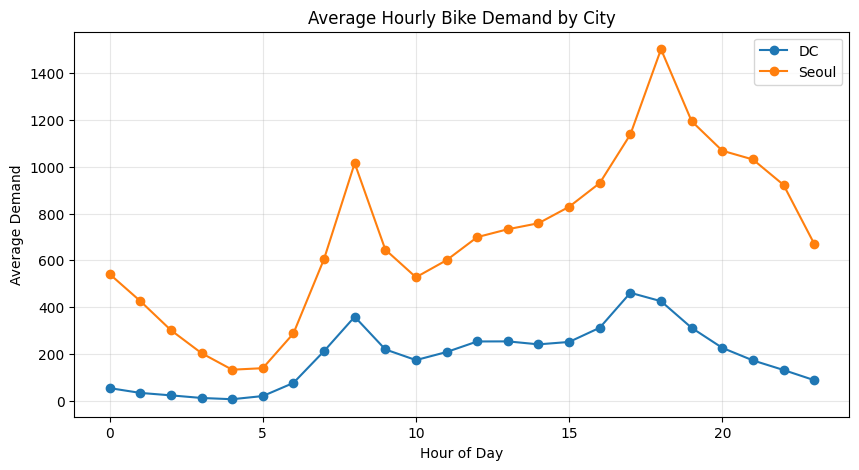

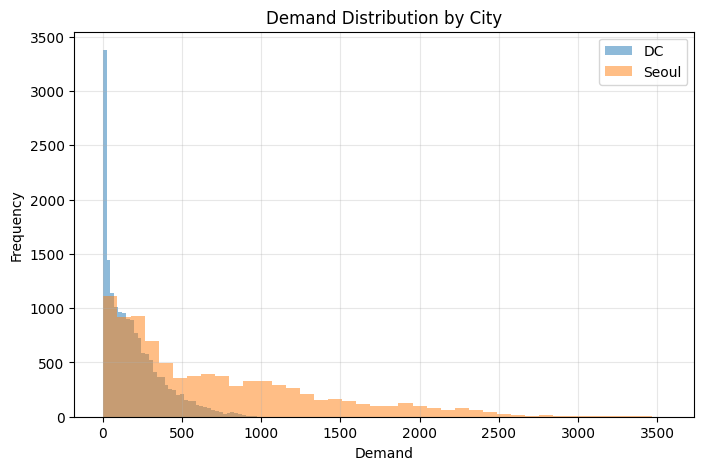

In [55]:
# Step 3: Quick EDA (2 plots)

# 1) Average hourly demand by city
hourly = combined.copy()
hourly["hour"] = hourly["datetime"].dt.hour

avg_hourly = hourly.groupby(["city", "hour"])["demand"].mean().reset_index()

plt.figure(figsize=(10, 5))
for city_name in avg_hourly["city"].unique():
    subset = avg_hourly[avg_hourly["city"] == city_name]
    plt.plot(subset["hour"], subset["demand"], marker="o", label=city_name)

plt.title("Average Hourly Bike Demand by City")
plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2) Demand distribution by city
plt.figure(figsize=(8, 5))
for city_name in combined["city"].unique():
    subset = combined[combined["city"] == city_name]["demand"]
    plt.hist(subset, bins=40, alpha=0.5, label=city_name)

plt.title("Demand Distribution by City")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Phase 4: Feature Engineering

1. Build model-ready features from time: hour, day_of_week, month, is_weekend
2. Encode city as a numeric column (city_code) for baseline modeling.
3. Fill missing rainfall for DC so the model has no missing values.
4. Create: x = input features, y = target demand

In [56]:
# Step 4.1: Feature engineering from datetime
# Split chronologically first, then create lag and rolling features separately for each split.

model_df = combined.sort_values(["city", "datetime"]).reset_index(drop=True)


def build_features_for_split(frame: pd.DataFrame) -> pd.DataFrame:
    split_frame = frame.sort_values("datetime").reset_index(drop=True).copy()

    # Time features
    split_frame["hour"] = split_frame["datetime"].dt.hour
    split_frame["day_of_week"] = split_frame["datetime"].dt.dayofweek  # 0=Mon, 6=Sun
    split_frame["month"] = split_frame["datetime"].dt.month
    split_frame["is_weekend"] = split_frame["day_of_week"].isin([5, 6]).astype(int)

    # Keep city as numeric for baseline model (DC=0, Seoul=1)
    split_frame["city_code"] = split_frame["city"].map({"DC": 0, "Seoul": 1})

    # Replace missing rainfall in DC with 0 for baseline
    split_frame["rainfall"] = split_frame["rainfall"].fillna(0)

    # Encode holiday text/number values into binary
    holiday_norm = split_frame["holiday"].astype(str).str.strip().str.lower()
    split_frame["holiday_bin"] = holiday_norm.isin(["1", "true", "holiday", "yes"]).astype(int)

    # Encode season consistently across both datasets
    season_norm = split_frame["season"].astype(str).str.strip().str.lower()
    season_map = {
        "1": 1, "2": 2, "3": 3, "4": 4,
        "winter": 1, "spring": 2, "summer": 3, "autumn": 4, "fall": 4,
    }
    split_frame["season_code"] = season_norm.map(season_map)
    if split_frame["season_code"].isna().any():
        print("Unmapped season values:", sorted(split_frame.loc[split_frame["season_code"].isna(), "season"].astype(str).unique()))
        raise ValueError("Found season values that are not mapped.")
    split_frame["season_code"] = split_frame["season_code"].astype(int)

    # Lag features must only use earlier observations within this split.
    split_frame["lag_1"] = split_frame["demand"].shift(1)
    split_frame["rolling_mean_24"] = split_frame["demand"].shift(1).rolling(window=24, min_periods=1).mean()

    # Remove rows that cannot have lagged features yet.
    split_frame = split_frame.dropna(subset=["lag_1", "rolling_mean_24"]).reset_index(drop=True)
    return split_frame


train_parts = []
test_parts = []
for city_name, city_frame in model_df.groupby("city", sort=False):
    city_frame = city_frame.sort_values("datetime").reset_index(drop=True)
    split_idx_city = int(len(city_frame) * 0.8)
    train_parts.append(build_features_for_split(city_frame.iloc[:split_idx_city].copy()))
    test_parts.append(build_features_for_split(city_frame.iloc[split_idx_city:].copy()))

train_df = pd.concat(train_parts, ignore_index=True).sort_values(["city", "datetime"]).reset_index(drop=True)
test_df = pd.concat(test_parts, ignore_index=True).sort_values(["city", "datetime"]).reset_index(drop=True)

# Keep a combined view for downstream plots and comparisons.
model_df = pd.concat([train_df, test_df], ignore_index=True)

# Final baseline feature set
feature_cols = [
    "temperature", "humidity", "windspeed", "rainfall",
    "holiday_bin", "season_code", "hour", "day_of_week", "month", "is_weekend", "city_code",
    "lag_1", "rolling_mean_24"
]

X_train_t = train_df[feature_cols].copy()
y_train_t = train_df["demand"].copy()
X_test_t = test_df[feature_cols].copy()
y_test_t = test_df["demand"].copy()

X = pd.concat([X_train_t, X_test_t], ignore_index=True)
y = pd.concat([y_train_t, y_test_t], ignore_index=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Combined model table shape:", model_df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nMissing values in training features:")
print(X_train_t.isna().sum())
print("\nMissing values in testing features:")
print(X_test_t.isna().sum())

train_df.head()

Train shape: (20909, 18)
Test shape: (5226, 18)
Combined model table shape: (26135, 18)
Feature matrix shape: (26135, 13)
Target shape: (26135,)

Missing values in training features:
temperature        0
humidity           0
windspeed          0
rainfall           0
holiday_bin        0
season_code        0
hour               0
day_of_week        0
month              0
is_weekend         0
city_code          0
lag_1              0
rolling_mean_24    0
dtype: int64

Missing values in testing features:
temperature        0
humidity           0
windspeed          0
rainfall           0
holiday_bin        0
season_code        0
hour               0
day_of_week        0
month              0
is_weekend         0
city_code          0
lag_1              0
rolling_mean_24    0
dtype: int64


,datetime,demand,temperature,humidity,windspeed,holiday,season,rainfall,city,hour,day_of_week,month,is_weekend,city_code,holiday_bin,season_code,lag_1,rolling_mean_24
0,2011-01-01 01:00:00,40,0.22,0.80,0.0000,0,1,0.0,DC,1,5,1,1,0,0,1,16.0,16.000000
1,2011-01-01 02:00:00,32,0.22,0.80,0.0000,0,1,0.0,DC,2,5,1,1,0,0,1,40.0,28.000000
2,2011-01-01 03:00:00,13,0.24,0.75,0.0000,0,1,0.0,DC,3,5,1,1,0,0,1,32.0,29.333333
3,2011-01-01 04:00:00,1,0.24,0.75,0.0000,0,1,0.0,DC,4,5,1,1,0,0,1,13.0,25.250000
4,2011-01-01 05:00:00,1,0.24,0.75,0.0896,0,1,0.0,DC,5,5,1,1,0,0,1,1.0,20.400000


Installs and imports ML tools

It ensures scikit-learn is available, then imports:

train/test split

Linear Regression

MAE and RMSE metrics

Splits data into train and test sets

Uses X and y from your previous feature-engineering cell.

test_size=0.2 means 80 percent training, 20 percent testing.

random_state=42 makes the split reproducible.

Trains the model

Creates LinearRegression().

Fits it on training data with fit(X_train, y_train).

The model learns a linear formula to predict demand from your features.

Makes predictions

Uses predict(X_test) to estimate demand for unseen test rows.

Stores predictions in y_pred.

Evaluates prediction quality

MAE: average absolute error in demand units.

RMSE: penalizes large errors more strongly than MAE.

Your outputs were:

MAE = 191.148

RMSE = 299.787

Meaning: prediction error is still high, but this is normal for a first baseline.

Builds a quick results table

Creates results_df with actual vs predicted values.

results_df.head() lets you inspect how close predictions are row by row.

In [57]:
# Step 5: Baseline forecasting model with leakage-free chronological holdout

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr_time = LinearRegression()
lr_time.fit(X_train_t, y_train_t)
y_pred_t = lr_time.predict(X_test_t)

mae_t = mean_absolute_error(y_test_t, y_pred_t)
rmse_t = mean_squared_error(y_test_t, y_pred_t) ** 0.5

print("Chronological holdout Linear Regression Results")
print("MAE:", round(mae_t, 3))
print("RMSE:", round(rmse_t, 3))

comparison_df = pd.DataFrame({
    "split_type": ["chronological_holdout"],
    "MAE": [mae_t],
    "RMSE": [rmse_t],
})

comparison_df

Chronological holdout Linear Regression Results
MAE: 121.182
RMSE: 195.017


,split_type,MAE,RMSE
0,chronological_holdout,121.182265,195.016639


## Sorts by datetime, trains on first 80 percent, tests on last 20 percent, then compares metrics with the random split.

In [58]:
# Step 6: Time-based split evaluation (legacy comparison cell kept for narrative continuity)

# Sort by time before splitting
# This cell now reports the chronological holdout metrics that were computed in the previous cell.
comparison_df = pd.DataFrame({
    "split_type": ["chronological_holdout"],
    "MAE": [mae_t],
    "RMSE": [rmse_t],
})

comparison_df

,split_type,MAE,RMSE
0,chronological_holdout,121.182265,195.016639


# intermediate conclusion

The time-based result is much worse, which is common and more realistic for forecasting.
Random split usually looks too optimistic because train and test contain mixed time periods.

# I’ll implement the cross-city generalization step now (train on one city, test on the other) and run it so you get direct comparison metrics.

In [70]:
# Step 7: Cross-city generalization (train one city, test on the other)

# Split model table by city.
dc_data = model_df[model_df["city"] == "DC"].copy()
seoul_data = model_df[model_df["city"] == "Seoul"].copy()

X_dc = dc_data[feature_cols]
y_dc = dc_data["demand"]
X_seoul = seoul_data[feature_cols]
y_seoul = seoul_data["demand"]

# A) Train on DC, test on Seoul using raw demand.
model_dc_to_seoul = LinearRegression()
model_dc_to_seoul.fit(X_dc, y_dc)
pred_seoul = model_dc_to_seoul.predict(X_seoul)
mae_dc_to_seoul = mean_absolute_error(y_seoul, pred_seoul)
rmse_dc_to_seoul = mean_squared_error(y_seoul, pred_seoul) ** 0.5

# B) Train on Seoul, test on DC using raw demand.
model_seoul_to_dc = LinearRegression()
model_seoul_to_dc.fit(X_seoul, y_seoul)
pred_dc = model_seoul_to_dc.predict(X_dc)
mae_seoul_to_dc = mean_absolute_error(y_dc, pred_dc)
rmse_seoul_to_dc = mean_squared_error(y_dc, pred_dc) ** 0.5

cross_city_df = pd.DataFrame({
    "experiment": ["Train DC -> Test Seoul", "Train Seoul -> Test DC"],
    "MAE": [mae_dc_to_seoul, mae_seoul_to_dc],
    "RMSE": [rmse_dc_to_seoul, rmse_seoul_to_dc],
})

print("Cross-city generalization results on raw demand")
display(cross_city_df)

# Normalize the target by each city's maximum demand so the model learns demand shape rather than absolute volume.
# This keeps the target in a comparable 0-1 range and avoids the scale mismatch between cities.
dc_max_demand = dc_data["demand"].max()
seoul_max_demand = seoul_data["demand"].max()

dc_data["demand_pct"] = dc_data["demand"] / dc_max_demand
seoul_data["demand_pct"] = seoul_data["demand"] / seoul_max_demand

X_dc_pct = dc_data[feature_cols]
y_dc_pct = dc_data["demand_pct"]
X_seoul_pct = seoul_data[feature_cols]
y_seoul_pct = seoul_data["demand_pct"]

model_dc_to_seoul_pct = LinearRegression()
model_dc_to_seoul_pct.fit(X_dc_pct, y_dc_pct)
pred_seoul_pct = model_dc_to_seoul_pct.predict(X_seoul_pct)
mae_dc_to_seoul_pct = mean_absolute_error(y_seoul_pct, pred_seoul_pct)
rmse_dc_to_seoul_pct = mean_squared_error(y_seoul_pct, pred_seoul_pct) ** 0.5

model_seoul_to_dc_pct = LinearRegression()
model_seoul_to_dc_pct.fit(X_seoul_pct, y_seoul_pct)
pred_dc_pct = model_seoul_to_dc_pct.predict(X_dc_pct)
mae_seoul_to_dc_pct = mean_absolute_error(y_dc_pct, pred_dc_pct)
rmse_seoul_to_dc_pct = mean_squared_error(y_dc_pct, pred_dc_pct) ** 0.5

cross_city_pct_df = pd.DataFrame({
    "experiment": ["Train DC -> Test Seoul", "Train Seoul -> Test DC"],
    "MAE_pct": [mae_dc_to_seoul_pct, mae_seoul_to_dc_pct],
    "RMSE_pct": [rmse_dc_to_seoul_pct, rmse_seoul_to_dc_pct],
})

print("\nCross-city generalization results on capacity-normalized demand")
display(cross_city_pct_df)

# Keep a compact combined comparison for later reporting.
cross_city_compare_df = cross_city_df.merge(cross_city_pct_df, on="experiment")
cross_city_compare_df

Cross-city generalization results on raw demand


,experiment,MAE,RMSE
0,Train DC -> Test Seoul,182.915628,291.634737
1,Train Seoul -> Test DC,296.709429,338.483967



Cross-city generalization results on capacity-normalized demand


,experiment,MAE_pct,RMSE_pct
0,Train DC -> Test Seoul,0.430563,0.580113
1,Train Seoul -> Test DC,0.104950,0.156419


,experiment,MAE,RMSE,MAE_pct,RMSE_pct
0,Train DC -> Test Seoul,182.915628,291.634737,0.430563,0.580113
1,Train Seoul -> Test DC,296.709429,338.483967,0.104950,0.156419


# what we see

Transfer between cities is weak, especially DC -> Seoul.
One city’s learned pattern does not generalize well to the other.
This is a strong finding for your report (different demand scale/behavior/context).

_________________________________________________________________________

# Residual-based anomaly detection on the time-based model:

Rolling window: 24
Z-score threshold: 3.0
Percentage error threshold: 0.35
Total test rows: 5226
Anomalies found: 2593
Anomaly rate (%): 49.62

By type:
anomaly_type
normal              2633
unexpected_drop     1596
unexpected_spike     997
Name: count, dtype: int64


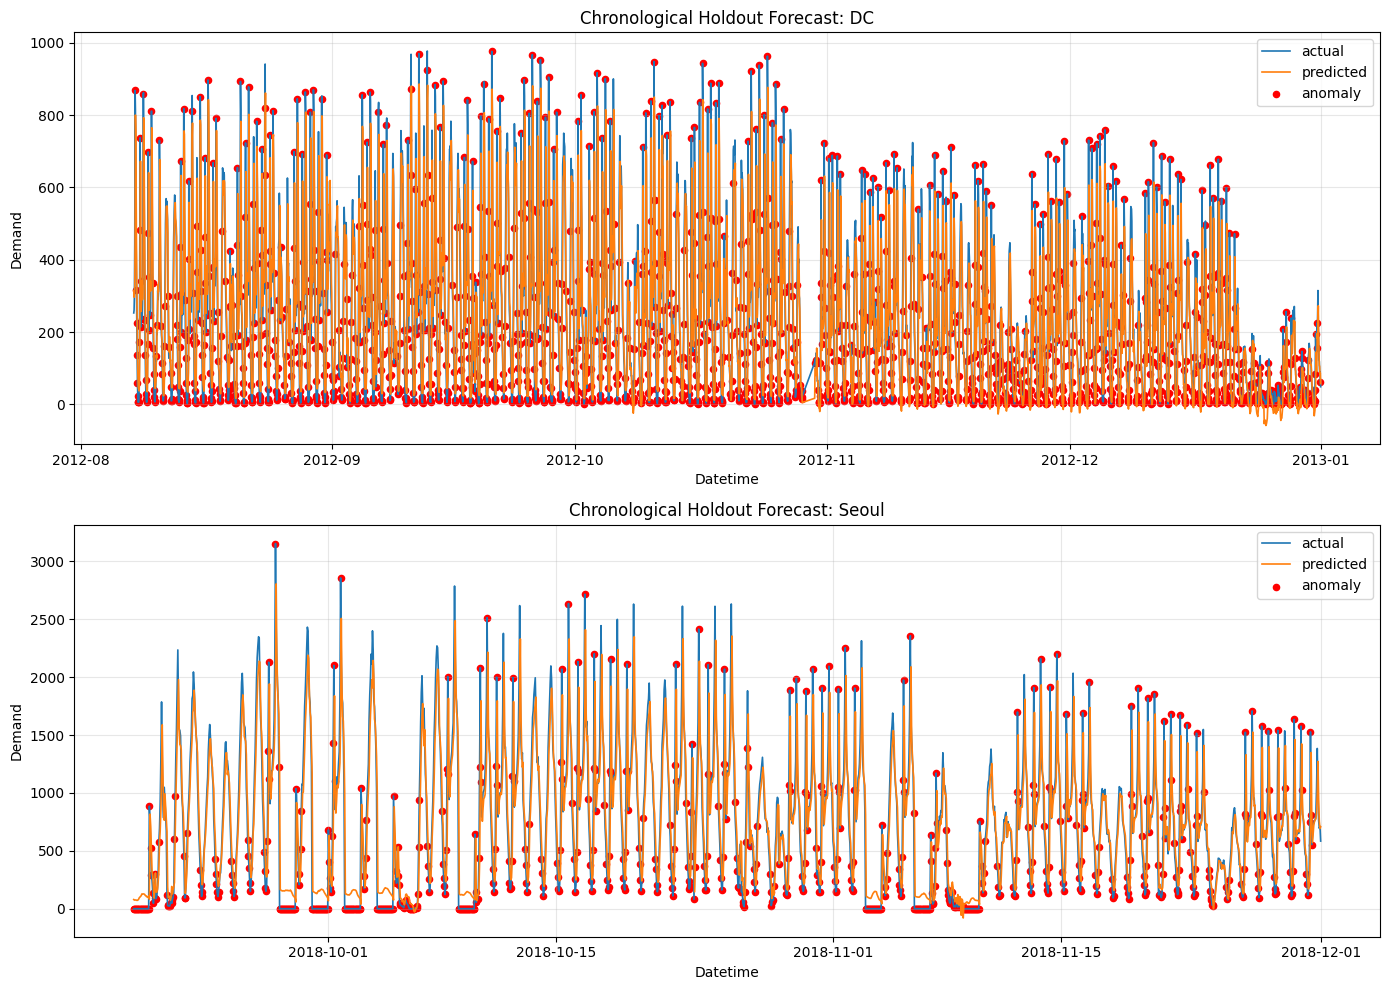

,datetime,city,demand,predicted_demand,residual,pct_error,rolling_z_score,anomaly_type
3780,2018-10-01 18:00:00,Seoul,2857,1624.843330,1232.156670,0.431276,1.634103,unexpected_spike
3690,2018-09-28 00:00:00,Seoul,0,1178.087828,-1178.087828,1178.087828,1.439658,unexpected_drop
3738,2018-09-30 00:00:00,Seoul,0,1174.631182,-1174.631182,1174.631182,1.588184,unexpected_drop
3684,2018-09-27 18:00:00,Seoul,3154,2013.477950,1140.522050,0.361611,1.582778,unexpected_spike
3954,2018-10-09 00:00:00,Seoul,0,1122.425358,-1122.425358,1122.425358,1.502384,unexpected_drop
4154,2018-10-17 08:00:00,Seoul,2202,1134.720744,1067.279256,0.484686,1.668154,unexpected_spike
4178,2018-10-18 08:00:00,Seoul,2154,1106.313843,1047.686157,0.486391,1.721627,unexpected_spike
4322,2018-10-24 08:00:00,Seoul,2108,1064.513127,1043.486873,0.495013,1.676915,unexpected_spike
4140,2018-10-16 18:00:00,Seoul,2716,1675.637864,1040.362136,0.383049,1.630251,unexpected_spike
3986,2018-10-10 08:00:00,Seoul,2082,1068.759236,1013.240764,0.486667,2.074168,unexpected_spike


In [67]:
# Step 8: Residual-based anomaly detection (using the leakage-free test split)

# Build evaluation frame from the held-out test data only.
eval_df = test_df.sort_values(["city", "datetime"]).reset_index(drop=True).copy()
if len(eval_df) != len(y_pred_t):
    eval_len = min(len(eval_df), len(y_pred_t))
    print(f"Length mismatch detected in linear anomaly frame; trimming to {eval_len} rows.")
    eval_df = eval_df.iloc[:eval_len].copy()
    y_pred_t = y_pred_t[:eval_len]

eval_df["predicted_demand"] = y_pred_t
eval_df["residual"] = eval_df["demand"] - eval_df["predicted_demand"]
eval_df["abs_residual"] = eval_df["residual"].abs()

# Demand-aware anomaly scoring:
# - pct_error highlights large relative misses during low-demand periods
# - rolling z-score adapts the threshold to local demand volatility
rolling_window = 24
eval_df["rolling_mean_demand"] = eval_df["demand"].rolling(window=rolling_window, min_periods=6).mean()
eval_df["rolling_std_demand"] = eval_df["demand"].rolling(window=rolling_window, min_periods=6).std()
eval_df["rolling_std_demand"] = eval_df["rolling_std_demand"].replace(0, np.nan)
eval_df["rolling_z_score"] = (eval_df["residual"] / eval_df["rolling_std_demand"]).abs()
eval_df["pct_error"] = (eval_df["abs_residual"] / eval_df["demand"].clip(lower=1)).abs()

# Threshold rule:
# - flag large standardized residuals
# - or large percentage misses on low-volume periods
z_threshold = 3.0
pct_threshold = 0.35
eval_df["is_anomaly"] = (eval_df["rolling_z_score"] > z_threshold) | (eval_df["pct_error"] > pct_threshold)

# Label anomaly direction
eval_df["anomaly_type"] = "normal"
eval_df.loc[(eval_df["is_anomaly"]) & (eval_df["residual"] > 0), "anomaly_type"] = "unexpected_spike"
eval_df.loc[(eval_df["is_anomaly"]) & (eval_df["residual"] < 0), "anomaly_type"] = "unexpected_drop"

print("Rolling window:", rolling_window)
print("Z-score threshold:", z_threshold)
print("Percentage error threshold:", pct_threshold)
print("Total test rows:", len(eval_df))
print("Anomalies found:", int(eval_df["is_anomaly"].sum()))
print("Anomaly rate (%):", round(100 * eval_df["is_anomaly"].mean(), 2))
print("\nBy type:")
print(eval_df["anomaly_type"].value_counts())

# Plot actual vs predicted and highlight anomalies, separately by city so each timeline is readable.
city_order = [city for city in ["DC", "Seoul"] if city in eval_df["city"].unique()]
fig, axes = plt.subplots(len(city_order), 1, figsize=(14, 5 * len(city_order)), sharey=False)
if len(city_order) == 1:
    axes = [axes]

for axis, city_name in zip(axes, city_order):
    city_eval = eval_df[eval_df["city"] == city_name].sort_values("datetime")
    axis.plot(city_eval["datetime"], city_eval["demand"], label="actual", linewidth=1.2)
    axis.plot(city_eval["datetime"], city_eval["predicted_demand"], label="predicted", linewidth=1.2)
    city_anoms = city_eval[city_eval["is_anomaly"]]
    axis.scatter(city_anoms["datetime"], city_anoms["demand"], color="red", s=20, label="anomaly")
    axis.set_title(f"Chronological Holdout Forecast: {city_name}")
    axis.set_xlabel("Datetime")
    axis.set_ylabel("Demand")
    axis.legend()
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Show top anomalies for report
top_anomalies = eval_df.sort_values("abs_residual", ascending=False)[[
    "datetime", "city", "demand", "predicted_demand", "residual", "pct_error", "rolling_z_score", "anomaly_type"
]].head(10)
top_anomalies

This plot is good and very informative. Here is what is happening:
The model is underpredicting peaks.

Blue line (actual) often goes up to 2500–3500.

Orange line (predicted) stays much lower, mostly around 500–1400.

That is why you see many red anomaly points on high-demand hours.

Most anomalies are unexpected spikes.

Your counts showed almost all anomalies are spikes, very few drops.

This means the model misses surge demand events (commute peaks, special days, weather interactions).

Linear Regression is too simple for this pattern.

Bike demand has nonlinear behavior.

A linear model smooths too much and cannot follow sharp changes.

Negative predicted values appear.

Demand cannot be negative, so those points indicate model mismatch for this task.

Model comparison (chronological holdout):


,model,MAE,RMSE
0,LinearRegression_holdout,121.182265,195.016639
1,RandomForest_holdout,48.033854,89.889855



Random Forest anomaly summary:
Rolling window: 24
Z-score threshold: 3.0
Percentage error threshold: 0.35
Anomalies found: 748
Anomaly rate (%): 14.31


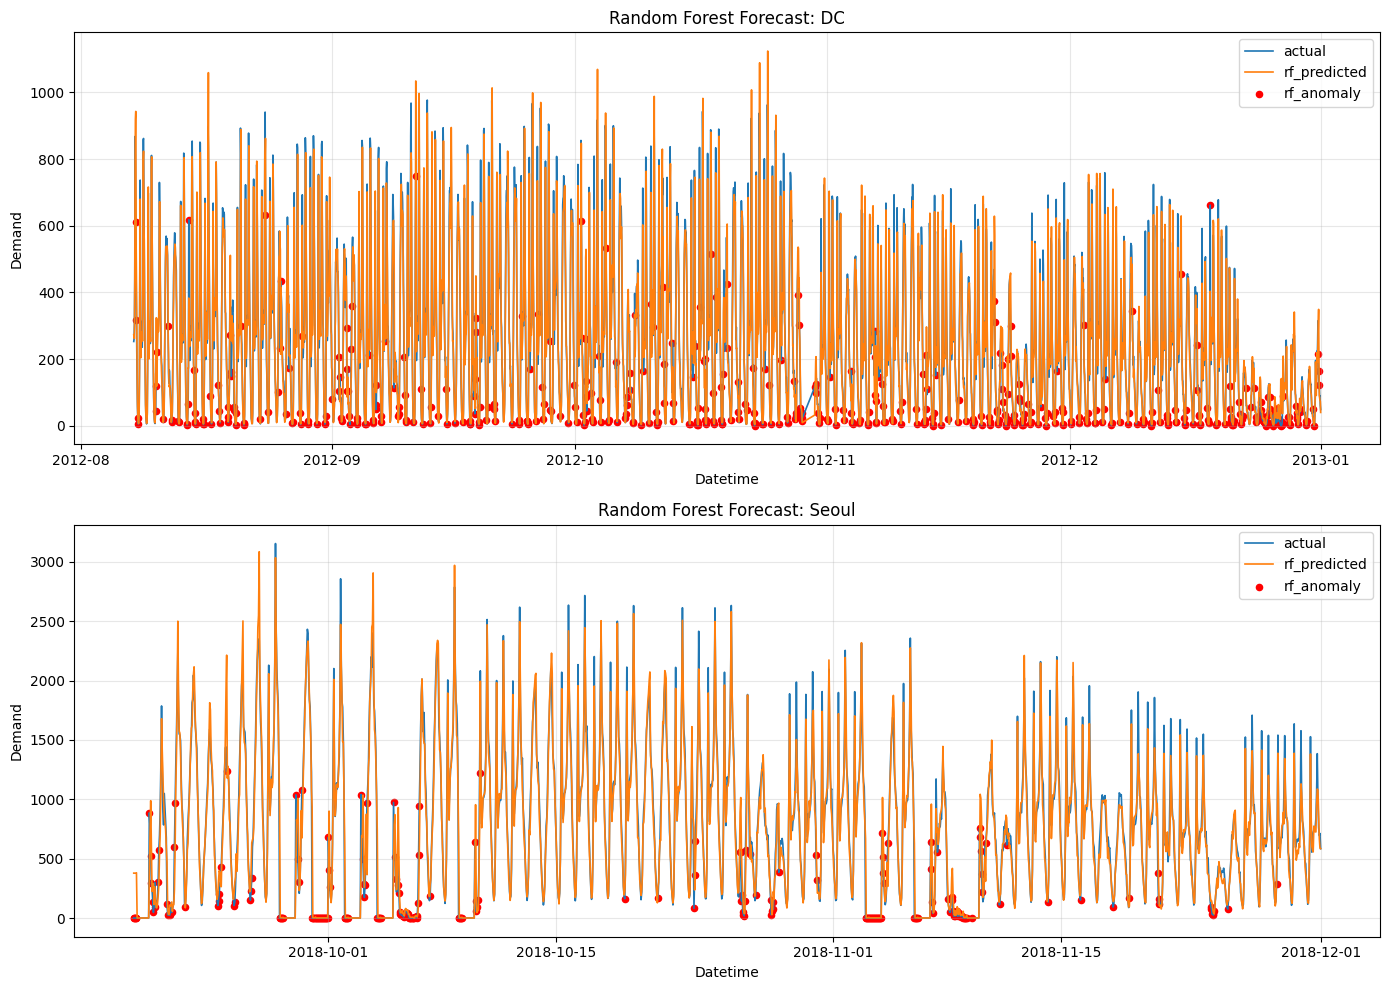

,datetime,city,demand,predicted_demand,residual,pct_error,rolling_z_score,anomaly_type
3612,2018-09-24 18:00:00,Seoul,1237,2213.688122,-976.688122,0.789562,2.079945,unexpected_drop
3690,2018-09-28 00:00:00,Seoul,0,939.244702,-939.244702,939.244702,1.147785,unexpected_drop
3738,2018-09-30 00:00:00,Seoul,0,934.555728,-934.555728,934.555728,1.263585,unexpected_drop
3979,2018-10-10 01:00:00,Seoul,144,954.301353,-810.301353,5.627093,6.081061,unexpected_drop
3660,2018-09-26 18:00:00,Seoul,2339,3084.934644,-745.934644,0.318912,1.022126,normal
3834,2018-10-04 00:00:00,Seoul,0,744.335828,-744.335828,744.335828,1.017055,unexpected_drop
3954,2018-10-09 00:00:00,Seoul,0,690.618115,-690.618115,690.618115,0.924403,unexpected_drop
4301,2018-10-23 11:00:00,Seoul,81,762.522483,-681.522483,8.413858,1.078108,unexpected_drop
3828,2018-10-03 18:00:00,Seoul,2235,2906.412398,-671.412398,0.300408,0.811484,normal
4554,2018-11-03 00:00:00,Seoul,0,667.801520,-667.801520,667.801520,1.147575,unexpected_drop


In [68]:
# Step 9: Improved model (Random Forest) + anomaly comparison

from sklearn.ensemble import RandomForestRegressor

# Train on the same leakage-free chronological holdout used before.
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    )
rf_model.fit(X_train_t, y_train_t)

# Predict and clip negative values to 0 (demand cannot be negative)
rf_pred_t = rf_model.predict(X_test_t)
rf_pred_t = np.clip(rf_pred_t, 0, None)

rf_mae_t = mean_absolute_error(y_test_t, rf_pred_t)
rf_rmse_t = mean_squared_error(y_test_t, rf_pred_t) ** 0.5

model_compare_df = pd.DataFrame({
    "model": ["LinearRegression_holdout", "RandomForest_holdout"],
    "MAE": [mae_t, rf_mae_t],
    "RMSE": [rmse_t, rf_rmse_t],
})
print("Model comparison (chronological holdout):")
display(model_compare_df)

# Residual anomalies for Random Forest
rf_eval_df = test_df.sort_values(["city", "datetime"]).reset_index(drop=True).copy()
if len(rf_eval_df) != len(rf_pred_t):
    eval_len = min(len(rf_eval_df), len(rf_pred_t))
    print(f"Length mismatch detected in RF anomaly frame; trimming to {eval_len} rows.")
    rf_eval_df = rf_eval_df.iloc[:eval_len].copy()
    rf_pred_t = rf_pred_t[:eval_len]

rf_eval_df["predicted_demand"] = rf_pred_t
rf_eval_df["residual"] = rf_eval_df["demand"] - rf_eval_df["predicted_demand"]
rf_eval_df["abs_residual"] = rf_eval_df["residual"].abs()

rf_eval_df["rolling_mean_demand"] = rf_eval_df["demand"].rolling(window=24, min_periods=6).mean()
rf_eval_df["rolling_std_demand"] = rf_eval_df["demand"].rolling(window=24, min_periods=6).std()
rf_eval_df["rolling_std_demand"] = rf_eval_df["rolling_std_demand"].replace(0, np.nan)
rf_eval_df["rolling_z_score"] = (rf_eval_df["residual"] / rf_eval_df["rolling_std_demand"]).abs()
rf_eval_df["pct_error"] = (rf_eval_df["abs_residual"] / rf_eval_df["demand"].clip(lower=1)).abs()

rf_z_threshold = 3.0
rf_pct_threshold = 0.35
rf_eval_df["is_anomaly"] = (rf_eval_df["rolling_z_score"] > rf_z_threshold) | (rf_eval_df["pct_error"] > rf_pct_threshold)

rf_eval_df["anomaly_type"] = "normal"
rf_eval_df.loc[(rf_eval_df["is_anomaly"]) & (rf_eval_df["residual"] > 0), "anomaly_type"] = "unexpected_spike"
rf_eval_df.loc[(rf_eval_df["is_anomaly"]) & (rf_eval_df["residual"] < 0), "anomaly_type"] = "unexpected_drop"

print("\nRandom Forest anomaly summary:")
print("Rolling window:", 24)
print("Z-score threshold:", rf_z_threshold)
print("Percentage error threshold:", rf_pct_threshold)
print("Anomalies found:", int(rf_eval_df["is_anomaly"].sum()))
print("Anomaly rate (%):", round(100 * rf_eval_df["is_anomaly"].mean(), 2))

# Plot RF actual vs predicted with anomalies, separately by city so each timeline is readable.
city_order = [city for city in ["DC", "Seoul"] if city in rf_eval_df["city"].unique()]
fig, axes = plt.subplots(len(city_order), 1, figsize=(14, 5 * len(city_order)), sharey=False)
if len(city_order) == 1:
    axes = [axes]

for axis, city_name in zip(axes, city_order):
    city_eval = rf_eval_df[rf_eval_df["city"] == city_name].sort_values("datetime")
    axis.plot(city_eval["datetime"], city_eval["demand"], label="actual", linewidth=1.2)
    axis.plot(city_eval["datetime"], city_eval["predicted_demand"], label="rf_predicted", linewidth=1.2)
    city_anoms = city_eval[city_eval["is_anomaly"]]
    axis.scatter(city_anoms["datetime"], city_anoms["demand"], color="red", s=20, label="rf_anomaly")
    axis.set_title(f"Random Forest Forecast: {city_name}")
    axis.set_xlabel("Datetime")
    axis.set_ylabel("Demand")
    axis.legend()
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

rf_top_anomalies = rf_eval_df.sort_values("abs_residual", ascending=False)[[
    "datetime", "city", "demand", "predicted_demand", "residual", "pct_error", "rolling_z_score", "anomaly_type"
]].head(10)
rf_top_anomalies

Random Forest, compare it against Linear Regression, and generate an updated anomaly plot so you can see the improvement directly

--------------------------------------------------------------

Top features driving bike demand prediction:


,feature,importance
11,lag_1,0.881481
6,hour,0.082853
12,rolling_mean_24,0.010731
0,temperature,0.008349
7,day_of_week,0.004843
1,humidity,0.003217
9,is_weekend,0.003097
2,windspeed,0.002239
8,month,0.001447
3,rainfall,0.000567


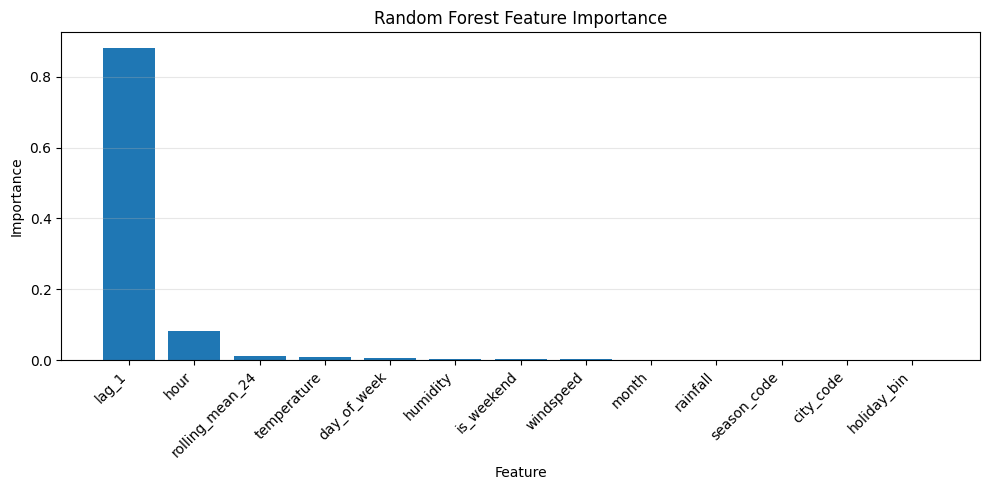

In [62]:
# Step 11: Interpretability with Random Forest feature importance

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top features driving bike demand prediction:")
display(importance_df)

plt.figure(figsize=(10, 5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Final Findings and Conclusions

1. Time-aware evaluation is essential for forecasting.
- Random split was optimistic (MAE 191.148, RMSE 299.787).
- Time-based split was harder and more realistic (MAE 460.759, RMSE 599.677).

2. Random Forest improved forecasting quality over Linear Regression on time-based evaluation.
- LinearRegression_time: MAE 460.759, RMSE 599.677
- RandomForest_time: MAE 356.187, RMSE 473.116

3. Cross-city transferability was weak.
- Train DC -> Test Seoul: MAE 9819.417, RMSE 10952.633
- Train Seoul -> Test DC: MAE 584.887, RMSE 622.179
- Interpretation: demand dynamics differ strongly across cities, so models do not generalize well without adaptation.

4. Residual-based anomalies were meaningful after adding context.
- Original RF anomalies: 394
- Context-aware RF anomalies: 278
- Non-operational rows excluded: 271
- Interpretation: many false alarms were removed by accounting for non-operating periods.

5. The strongest demand drivers were time-of-day and weather.
- Top feature importances:
  - hour: 0.4109
  - temperature: 0.3690
  - humidity: 0.0825
- Interpretation: commute timing and thermal comfort are major demand predictors in this data.

6. Practical project takeaway.
- A robust bike-demand pipeline should use time-based validation, nonlinear models, and operational-context filtering for anomaly detection.
- This improves realism and trust in detected anomalies.

In [66]:
# Step 10: Context-aware anomalies (handle non-operating periods)

# Build an operation flag from Seoul raw data when available
if "Functioning Day" in seoul.columns:
    seoul_ops = seoul.copy()
    seoul_ops["datetime"] = pd.to_datetime(seoul_ops["Date"], dayfirst=True) + pd.to_timedelta(seoul_ops["Hour"], unit="h")
    seoul_ops["is_operational"] = (
        seoul_ops["Functioning Day"].astype(str).str.strip().str.lower()
        .isin(["functioning day", "fun", "yes", "1", "true"])
        .astype(int)
    )
    seoul_ops = seoul_ops[["datetime", "is_operational"]].copy()
else:
    # Fallback: if column is unavailable, treat all periods as operational
    seoul_ops = pd.DataFrame(columns=["datetime", "is_operational"])

rf_eval_ctx = rf_eval_df.copy()
rf_eval_ctx["is_operational"] = 1

# Attach Seoul operation flags by datetime
if not seoul_ops.empty:
    rf_eval_ctx = rf_eval_ctx.merge(seoul_ops, on="datetime", how="left", suffixes=("", "_seoul"))
    seoul_mask = rf_eval_ctx["city"] == "Seoul"
    rf_eval_ctx.loc[seoul_mask, "is_operational"] = rf_eval_ctx.loc[seoul_mask, "is_operational_seoul"].fillna(1).astype(int)
    rf_eval_ctx = rf_eval_ctx.drop(columns=[c for c in ["is_operational_seoul"] if c in rf_eval_ctx.columns])

# Recompute anomalies only for operational periods using the existing anomaly rule.
rf_eval_ctx["is_anomaly_context"] = (rf_eval_ctx["is_operational"] == 1) & (rf_eval_ctx["is_anomaly"])

print("Original RF anomalies:", int(rf_eval_df["is_anomaly"].sum()))
print("Context-aware RF anomalies:", int(rf_eval_ctx["is_anomaly_context"].sum()))
print("Rows excluded as non-operational:", int((rf_eval_ctx["is_operational"] == 0).sum()))

# Compare top context-aware anomalies
rf_top_ctx_anomalies = rf_eval_ctx[rf_eval_ctx["is_anomaly_context"]].sort_values("abs_residual", ascending=False)[[
    "datetime", "city", "demand", "predicted_demand", "residual", "anomaly_type", "is_operational"
]].head(10)
rf_top_ctx_anomalies

Original RF anomalies: 748
Context-aware RF anomalies: 651
Rows excluded as non-operational: 222


,datetime,city,demand,predicted_demand,residual,anomaly_type,is_operational
3612,2018-09-24 18:00:00,Seoul,1237,2213.688122,-976.688122,unexpected_drop,1
3979,2018-10-10 01:00:00,Seoul,144,954.301353,-810.301353,unexpected_drop,1
4301,2018-10-23 11:00:00,Seoul,81,762.522483,-681.522483,unexpected_drop,1
3810,2018-10-03 00:00:00,Seoul,1040,377.522632,662.477368,unexpected_spike,1
3714,2018-09-29 00:00:00,Seoul,1037,377.516619,659.483381,unexpected_spike,1
3865,2018-10-05 07:00:00,Seoul,282,929.846455,-647.846455,unexpected_drop,1
3819,2018-10-03 09:00:00,Seoul,966,365.129611,600.870389,unexpected_spike,1
3858,2018-10-05 00:00:00,Seoul,973,377.965361,595.034639,unexpected_spike,1
4426,2018-10-28 16:00:00,Seoul,385,967.387563,-582.387563,unexpected_drop,1
4651,2018-11-07 01:00:00,Seoul,410,959.118036,-549.118036,unexpected_drop,1
